# Universidade Federal de São João del-Rei

# Machine Learning Aplicado à Engenharia

# Trabalho 1 (T1) — Análise de Dados Reais em Python

**Tema:** Análise Exploratória de Sinais EEG para Monitoramento e Classificação de Estados de Sono em Janelas de 30 Segundos

**Base utilizada:** _Sleep-EDF Database Expanded_

**Fonte:** https://www.physionet.org/content/sleep-edfx/1.0.0/

# Referência da Base

- B Kemp, AH Zwinderman, B Tuk, HAC Kamphuisen, JJL Oberyé. _Analysis of a sleep-dependent neuronal feedback loop: the slow-wave microcontinuity of the EEG_. IEEE-BME 47(9):1185-1194 (2000).

# Citação Padrão para PhysioNet

- Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, PC, Mark, R., ... & Stanley, HE (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

**Integrantes do grupo:**
- Ícaro Ferreira dos Santos
- Wendell Christian Calixto Pinto
- Gabriel Augusto Silva Batista

**Repositório do grupo:**  
https://github.com/gabrielbtt/analise-estados-sono-eeg

# Convenção de Cores para Identificar Contribuições
- <font color="blue">Azul:</font> Ícaro Ferreira dos Santos
- <font color="green">Verde:</font> Wendell Christian Calixto Pinto
- <font color="red">Vermelho:</font> Gabriel Augusto Silva Batista

# Definição do Problema <font color="blue">(Ícaro)</font>

## Descrição do Tema
A polissonografia é o exame mais completo para estudar o sono. Ela registra sinais do cérebro (EEG), movimentos dos olhos (EOG) e atividade muscular (EMG) enquanto a pessoa dorme. Os técnicos analisam esses sinais manualmente, dividindo a noite em blocos de 30 segundos (épocas), conforme o padrão internacional Rechtschaffen & Kales (1968).

Em cada bloco, eles observam as ondas cerebrais e decidem qual estágio do sono está ocorrendo. Essa análise manual é demorada e depende da experiência de cada técnico, o que pode gerar diferenças entre profissionais.

Os estágios do sono são:

- W (Vigília): momento em que a pessoa está acordada ou quase acordando;
- N1: sono leve de transição (fácil de acordar);
- N2: sono mais estável, que ocupa a maior parte da noite;
- N3: sono profundo, importante para recuperação física do corpo;
- R (REM): sono dos sonhos, essencial para a memória e o equilíbrio emocional.

A forma como esses estágios se distribuem durante a noite é chamada de arquitetura do sono. Quando essa distribuição está alterada, por exemplo, redução de N3 e REM ou aumento excessivo de N1 e vigília, a pessoa pode acordar cansada mesmo tendo dormido muitas horas. Isso ocorre em distúrbios como apneia obstrutiva do sono (distúrbio grave caracterizado por pausas repetidas da respiração durante o sono), insônia (dificuldade para iniciar ou manter o sono, ou despertar precoce), parassonias (como sonambulismo e terror noturno) e narcolepsia (sonolência diurna excessiva), impactando diretamente a qualidade de vida e a saúde geral do indivíduo.

## A Pergunta Principal Deste Estudo é:
Quais padrões estatísticos, morfológicos e temporais estão presentes nas janelas de 30 segundos dos sinais EEG do banco _Sleep-EDF Expanded_ (base pública amplamente utilizada para pesquisa em detecção e classificação de estágios do sono, disponível na plataforma [PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/)), e como esses padrões podem contribuir para o desenvolvimento de um sistema automático de classificação dos estágios do sono (vigília, N1, N2, N3 ou REM)?

## Justificativa da Relevância
Analisar os dados em janelas de 30 segundos permite alinhar o trabalho computacional com a forma como os médicos realmente analisam o sono.
Essa divisão reduz muito a quantidade de dados e permite calcular variáveis úteis para cada bloco, tais como a média e a variação da amplitude do sinal (atividade elétrica do cérebro medida em microvolts ao longo do tempo), se o sinal apresenta assimetria e transientes (característicos da instabilidade da vigília e N1) ou se exibe sincronia e estabilidade estatística (características do sono profundo) e a relação entre a atividade elétrica e o estágio do sono (vigília, N1, N2, N3 ou REM).

Essas variáveis ajudam a caracterizar e a entender melhor o que está acontecendo em cada bloco de 30 segundos e servem como base para o treinamento de modelos de aprendizado de máquina, visando uma classificação automática dos estágios do sono. Com isso, o objetivo é tornar a análise mais rápida, mais objetiva e menos dependente da análise manual feita pelos técnicos.

# Fonte e Obtenção dos Dados <font color="red">(Gabriel)</font>

## Formato de Obtenção dos Dados
 Os dados dos sinais polissonográficos (arquivos com extensão .PSG.edf) estão no formato EDF (European Data Format*), contendo EEG (eletrodos Fpz-Cz e Pz-Oz), EOG (horizontal), EMG submentoniano, um marcador de evento e, geralmente, também sinais de respiração oronasal e temperatura corporal retal. Os hipnogramas, anotações dos estágios do sono, armazenados em arquivos com extensão *.Hypnogram.edf, estão no formato EDF+. Os arquivos são nomeados no padrão SC4 ssN EO-PSG.edf, em que "ss" corresponde ao número do sujeito e "N" à noite de coleta.

## Como os Dados Foram Obtidos
Os dados foram obtidos da base de dados pública _Sleep-EDF Expanded_, disponível em PhysioNet. Um script em Python, localizado no diretório src/, foi utilizado para converter os arquivos no formato EDF para CSV, facilitando a leitura e a manipulação dos dados. Os arquivos utilizados neste trabalho são SC4001E0-PSG.edf e SC4001EC-Hypnogram.edf, ambos armazenados no diretório dados/edfs_originais.

## Observações Sobre Confiabilidade e Contexto
A base de dados pública _Sleep-EDF Expanded_ é uma base de dados confiável e amplamente adotada pela comunidade científica dedicada ao estudo do sono. Os registros são provenientes do estudo “_Sleep Cassette_”, realizado entre 1987 e 1991, com participantes na faixa etária de 25 a 101 anos. Os estágios do sono (hipnograma) foram anotados manualmente por técnicos treinados, seguindo o padrão Rechtschaffen & Kales (1968).

## Limitações
Amostragem de 100 Hz, apenas dois canais principais de EEG (Fpz-Cz e Pz-Oz), e o estudo fornece apenas duas noites por paciente. Neste trabalho foi utilizada apenas uma noite de um paciente, o que limita a generalização, mas permite uma análise exploratória detalhada. A base pode ser expandida futuramente com mais pacientes e noites.

## Justificativa da Escolha da Base de Dados
Esta base foi escolhida por ser composta por dados reais de polissonografia, provenientes de fonte confiável (PhysioNet), e por apresentar anotações clínicas dos estágios do sono realizadas manualmente em épocas de 30 segundos, padrão adotado na prática clínica. A base permite a realização de análise exploratória completa, com estatística descritiva, distribuições e correlações; a aplicação de conceitos de organização e preparação de dados em Python; e a preparação conceitual para uma futura tarefa de classificação dos estágios do sono por meio de aprendizado de máquina. Ademais, sua estrutura temporal facilita o agrupamento dos dados em janelas de 30 segundos, reduzindo o volume de informações de forma clinicamente significativa.

# Leitura e Organização da Base em Python <font color="red">(Gabriel)</font>

## Carregamento da Base de Dados

In [ ]:
# Clonar o repositório
!git clone https://github.com/gabrielbtt/analise-estados-sono-eeg.git

Cloning into 'analise-estados-sono-eeg'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 158 (delta 67), reused 31 (delta 7), pack-reused 28 (from 1)
Receiving objects: 100% (158/158), 83.21 MiB | 9.16 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Updating files: 100% (27/27), done.


In [ ]:
# Entrar na pasta do projeto
%cd analise-estados-sono-eeg

/content/analise-estados-sono-eeg


In [ ]:
# Verificar se os arquivos estão lá
!ls -la

total 72
drwxr-xr-x 10 root root  4096 Apr 22 11:52 .
drwxr-xr-x  1 root root  4096 Apr 22 11:52 ..
-rw-r--r--  1 root root 13504 Apr 22 11:52 ambiente.yml
drwxr-xr-x  2 root root  4096 Apr 22 11:52 analise-estados-sono-eeg
drwxr-xr-x  2 root root  4096 Apr 22 11:52 apresentacao
drwxr-xr-x  5 root root  4096 Apr 22 11:52 dados
drwxr-xr-x  2 root root  4096 Apr 22 11:52 docs
drwxr-xr-x  2 root root  4096 Apr 22 11:52 figuras
drwxr-xr-x  8 root root  4096 Apr 22 11:52 .git
drwxr-xr-x  5 root root  4096 Apr 22 11:52 notebooks
-rw-r--r--  1 root root  1165 Apr 22 11:52 README.md
drwxr-xr-x  2 root root  4096 Apr 22 11:52 src
-rw-r--r--  1 root root  8496 Apr 22 11:52 trabalho1_enunciado.ipynb


In [ ]:
!pip install mne

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from IPython.display import display

# Carregamento da Base de Dados
# Pasta com os arquivos EDF originais
dados_dir = Path("dados/edfs_originais")
# Pasta onde o CSV final sera salvo
saida_dir = Path("dados/brutos")
dados_dir

# Leitura e organização
# Extrai a chave comum usada para juntar PSG e hypnograma
def peganome(filename: str) -> str:
    base = Path(filename).name.split("-")[0]
    return base[:7]

# Procura os arquivos e monta os pares correspondentes
def encontrapar(data_dir: Path, prefix="SC"):
    arquivospsg = sorted(data_dir.glob(f"{prefix}*-PSG.edf"))
    arquivoshyp = sorted(data_dir.glob(f"{prefix}*-Hypnogram.edf"))
    # dicionarios para buscar os arquivos pela chave do paciente/noite
    dicpsg = {peganome(arquivo.name): arquivo for arquivo in arquivospsg}
    dichyp = {peganome(arquivo.name): arquivo for arquivo in arquivoshyp}
    # mantem apenas as chaves que possuem os dois arquivos
    dicjunto = sorted(set(dicpsg) & set(dichyp))
    return [(k, dicpsg[k], dichyp[k]) for k in dicjunto]

# Gera a lista de pares validos
pares = encontrapar(dados_dir, prefix="SC")
len(pares), pares[:5]

# Escolher quantidade de noites pra analisar
totalpares = 10
# Seleciona só os primeiros pares para teste
selecpares = pares[:totalpares]
selecpares

# Conferir se par foi carregado corretamente
chavepar, caminhopsg, caminhohyp = selecpares[0]

# le o sinal bruto e as anotacoes do hypnograma
bruto = mne.io.read_raw_edf(caminhopsg, preload=False, infer_types=True, verbose="ERROR")
anot = mne.read_annotations(caminhohyp)

print(f"Chave do par: {chavepar}")
print(f"PSG: {caminhopsg}")
print(f"Hypnograma: {caminhohyp}")
print(f"Canais: {bruto.ch_names}")
print(f"Frequencia de amostragem: {bruto.info['sfreq']} Hz")
print("\nPrimeiras anotacoes:")
# Mostra um resumo inicial para validar as classes e os tempos
print(pd.DataFrame({
    "Inicio(s)": anot.onset[:10],
    "Duracao(s)": anot.duration[:10],
    "Classificacao": anot.description[:10]
}))

# Juntar em blocos de 30s, juntar estágio 3 e 4, selecionar canal principal, juntar com anotações, remover longas partes do acordado, extrair dados
# Tamanho padrão de cada época em segundos
SEGUNDOS_EPOCA = 30.0
# Faixa do filtro passa-banda aplicada ao EEG
FREQ_CORTE_BAIXA = 0.5
FREQ_CORTE_ALTA = 30.0
# Canal principal usado na análise
CANAL_EEG = "Fpz-Cz"
# Pares e pasta final reaproveitados nas próximas células
pares_sel = selecpares
PASTA_SAIDA = saida_dir
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

# Mapeia os rótulos do hypnograma para ids numéricos
AnotacaoParaId = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4, # juntar estagio 3 e 4
    "Sleep stage 4": 4, # juntar estagio 3 e 4
    "Sleep stage R": 5,
}

# Traduz os ids para os nomes das classes finais
IdPraClassificacao = {
    1: "Acordado",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM"
}

# Valida se o canal desejado existe no arquivo lido
def escolher_canal(bruto, escolha="Fpz-Cz"):
    if escolha in bruto.ch_names:
        return escolha
    else:
        raise ValueError(f"Canal {escolha} nao encontrado. Canais disponiveis: {bruto.ch_names}")

# Calcula a potência de uma faixa de frequência usando Welch
def calcular_potencia_banda(x, fs, fmin, fmax):
    amostras_janela = min(len(x), int(4 * fs))
    frequencias, densidade_potencia = welch(x, fs=fs, nperseg=amostras_janela)
    mascara_banda = (frequencias >= fmin) & (frequencias <= fmax)
    if not np.any(mascara_banda):
        return 0.0
    return trapezoid(densidade_potencia[mascara_banda], frequencias[mascara_banda])

# Extrai estatísticas simples e potências por banda de uma época
def extrair_dados_epocas(x, fs):
    delta = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=4)
    theta = calcular_potencia_banda(x, fs=fs, fmin=4, fmax=8)
    alpha = calcular_potencia_banda(x, fs=fs, fmin=8, fmax=13)
    beta = calcular_potencia_banda(x, fs=fs, fmin=13, fmax=30)
    total = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=30)
    eps = 1e-12
    return {
        "media": np.mean(x),
        "desvio_padrao": np.std(x, ddof=1),
        "variancia": np.var(x, ddof=1),
        "minimo": np.min(x),
        "maximo": np.max(x),
        "pico_a_pico": np.ptp(x),
        "valor_rms": np.sqrt(np.mean(x**2)),
        "assimetria": skew(x, bias=False),
        "curtose_excesso": kurtosis(x, fisher=True, bias=False),
        "potencia_delta": delta,
        "potencia_theta": theta,
        "potencia_alpha": alpha,
        "potencia_beta": beta,
        "potencia_total": total,
        "relativo_delta": delta / (total + eps),
        "relativo_theta": theta / (total + eps),
        "relativo_alpha": alpha / (total + eps),
        "relativo_beta": beta / (total + eps),
        "razao_delta_theta": delta / (theta + eps),
        "razao_delta_alpha": delta / (alpha + eps),
    }

Chave do par: SC4001E
PSG: dados/edfs_originais/SC4001E0-PSG.edf
Hypnograma: dados/edfs_originais/SC4001EC-Hypnogram.edf
Canais: ['Fpz-Cz', 'Pz-Oz', 'horizontal', 'oro-nasal', 'submental', 'rectal', 'Event marker']
Frequencia de amostragem: 100.0 Hz

Primeiras anotacoes:
   Inicio(s)  Duracao(s)  Classificacao
0        0.0     30630.0  Sleep stage W
1    30630.0       120.0  Sleep stage 1
2    30750.0       390.0  Sleep stage 2
3    31140.0        30.0  Sleep stage 3
4    31170.0        30.0  Sleep stage 2
5    31200.0       150.0  Sleep stage 3
6    31350.0        30.0  Sleep stage 4
7    31380.0        60.0  Sleep stage 3
8    31440.0        60.0  Sleep stage 4
9    31500.0        30.0  Sleep stage 3


## Observação Sobre as Bandas de Frequência
As faixas de frequência utilizadas neste trabalho seguem o padrão convencional da literatura de EEG e polissonografia. Elas foram escolhidas porque capturam as principais características fisiológicas associadas aos diferentes estágios do sono.

- Delta (0,5 – 4 Hz): Ondas lentas, predominantes no sono profundo (N3). Relacionadas à restauração física.
- Theta (4 – 8 Hz): Presentes no sono leve (N1 e N2) e em estados de relaxamento.
- Alpha (8 – 13 Hz): Características do estado de vigília relaxada ou transição para o sono.
- Beta (13 – 30 Hz): Ondas rápidas, associadas à vigília ativa, atenção e alerta.

A faixa total analisada (0,5 – 30 Hz) cobre a maioria das frequências relevantes para o estudo do sono, excluindo ruídos de baixa frequência (< 0,5 Hz) e de alta frequência (> 30 Hz), que geralmente não são clinicamente significativos para classificação de estágios do sono.
Essas bandas foram calculadas utilizando o método Welch (função [welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html) da SciPy) em cada época de 30 segundos.

## Padronizações e Transformações Relevantes
As seguintes padronizações e transformações foram aplicadas durante o processamento dos arquivos EDF para gerar o arquivo processado:

- Cada época corresponde exatamente a 30 segundos de sinal, seguindo o padrão clínico.
- Os estágios 3 e 4 foram combinados em uma única classe “N3” (sono profundo), conforme recomendação na documentação do [MNE-Python](https://mne.tools/stable/auto_tutorials/clinical/60_sleep.html?utm_source=chatgpt.com).
- Foi utilizado apenas o canal Fpz-Cz para extração de _features_, simplificando a análise sem perda significativa de informação relevante.
- Aplicação de filtro passa-banda (0,5 – 30 Hz), que remove ruídos de baixa e alta frequência que não são relevantes para a classificação de estágios do sono.
- Para cada época foram extraídas _features_ de medidas de tendência central, dispersão, forma da distribuição e potência em diferentes bandas de frequência (delta, theta, alpha, beta).


## Justificativa das Escolhas Realizadas
- O agrupamento em janelas de 30 segundos é exatamente o que os médicos classificam o sono na prática. Sem essa divisão, o volume de dados (2,5 milhões de amostras) tornaria a análise inviável.
- A união dos estágios 3 e 4 em uma única classe “N3” segue o que é comumente feito na documentação da classificação dos estágios do sono, pois ambos representam o sono profundo.
- A seleção do canal Fpz-Cz foi feita porque é um dos canais principais de EEG utilizados em estudos de sono e fornece boa informação sobre a atividade cerebral.
- A aplicação do filtro passa-banda (0,5 a 30 Hz) serve para remover ruídos que não são importantes para distinguir os estágios do sono.
- A extração de medidas como média, desvio padrão, assimetria, curtose e potência em diferentes bandas de frequência (delta, theta, alpha, beta) foi realizada porque essas variáveis capturam características importantes do sinal EEG. Elas ajudam a diferenciar os estágios do sono e preparam os dados para uma futura etapa de aprendizado de máquina.

# Tratamento e Preparação dos Dados <font color="green">(Wendell)</font>





In [ ]:
# Encontra o intervalo útil do sono com margem antes e depois
def lim_sono(anot, margem_segundos=1800):
    # Classes consideradas como sono real
    estagios_sono = {
        "Sleep stage 1",
        "Sleep stage 2",
        "Sleep stage 3",
        "Sleep stage 4",
        "Sleep stage R",
    }
    ind_sono = np.where(np.isin(anot.description, list(estagios_sono)))[0]

    # Se não houver sono anotado, mantém a janela inteira
    if len(ind_sono) == 0:
        return 0, anot.onset[-1] + anot.duration[-1]

    primeiro_ind = ind_sono[0]
    ultimo_ind = ind_sono[-1]

    ini_recorte = max(0, anot.onset[primeiro_ind] - margem_segundos)
    fim_recorte = anot.onset[ultimo_ind] + anot.duration[ultimo_ind] + margem_segundos

    return ini_recorte, fim_recorte


In [ ]:
# Recorta as anotações para ficar apenas com a janela útil do sono
def recortar_anotacoes_sono(anot, margem_segundos=1800):
    ini_recorte, fim_recorte = lim_sono(anot, margem_segundos=margem_segundos)
    anot_recortada = anot.copy()
    anot_recortada.crop(tmin=ini_recorte, tmax=fim_recorte)
    return anot_recortada

# Processa um par PSG + hypnograma e devolve um dataframe de épocas
def processar_par(caminhopsg, caminhohyp, chavepar):
    # carrega o sinal e as anotacoes do par atual
    bruto = mne.io.read_raw_edf(caminhopsg, preload=True, infer_types=True, verbose="ERROR")
    anot = mne.read_annotations(caminhohyp)

    # Limita a análise a janela útil do sono
    anot = recortar_anotacoes_sono(anot, margem_segundos=1800)
    bruto.set_annotations(anot, emit_warning=False)

    # Escolhe o canal principal e aplica o filtro
    canal_alvo = escolher_canal(bruto, CANAL_EEG)
    bruto.pick([canal_alvo])
    bruto.filter(FREQ_CORTE_BAIXA, FREQ_CORTE_ALTA, fir_design="firwin", verbose="ERROR")

    fs = float(bruto.info["sfreq"])

    # Transforma as anotações em eventos de 30 segundos
    eventos, _ = mne.events_from_annotations(
        bruto,
        event_id=AnotacaoParaId,
        chunk_duration=SEGUNDOS_EPOCA,
        verbose="ERROR",
    )

    # Gera as épocas alinhadas aos eventos encontrados
    epocas = mne.Epochs(
        bruto,
        eventos,
        event_id=None,
        tmin=0.0,
        tmax=SEGUNDOS_EPOCA - 1.0 / fs,
        baseline=None,
        preload=True,
        verbose="ERROR",
    )

    dados = epocas.get_data(copy=False)
    codigos_estagios = epocas.events[:, 2]
    amostras_eventos = epocas.events[:, 0]

    linhas = []
    for i in range(len(epocas)):
        x = dados[i, 0, :]
        # extrai as features da epoca atual
        feat = extrair_dados_epocas(x, fs=fs)

        # Monta uma linha com metadados e features das épocas
        linha = {
            "chavepar": chavepar,
            "arquivo_psg": caminhopsg.name,
            "arquivo_hyp": caminhohyp.name,
            "canal": canal_alvo,
            "frequencia_amostragem_hz": fs,
            "indice_epoca": i,
            "inicio_epoca_s": amostras_eventos[i] / fs,
            "id_estagio": int(codigos_estagios[i]),
            "estagio": IdPraClassificacao.get(int(codigos_estagios[i]), "OUTRO"),
        }
        linha.update(feat)
        linhas.append(linha)

    return pd.DataFrame(linhas)

# Exemplo com o primeiro par selecionado
df_exemplo = processar_par(caminhopsg, caminhohyp, chavepar)
print(f"{chavepar}: {len(df_exemplo)} epocas")
df_exemplo.head()


SC4001E: 841 epocas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


In [ ]:
import traceback

dfs = []

# Processa todos os pares selecionados e acumula os dataframes
for chavepar, caminhopsg, caminhohyp in pares_sel:
    print(f"\nProcessando {chavepar}")
    print("PSG:", caminhopsg)
    print("HYP:", caminhohyp)

    try:
        df_i = processar_par(caminhopsg, caminhohyp, chavepar)
        dfs.append(df_i)
        print(f"{chavepar}: {len(df_i)} epocas")
    except Exception as e:
        print(f"Erro em {chavepar}: {type(e).__name__}: {e}")
        traceback.print_exc()

if len(dfs) == 0:
    raise RuntimeError(
        "Nenhum arquivo foi processado com sucesso. "
        "Veja os erros impressos acima."
    )

# Junta tudo em um único dataframe e salva em CSV
df = pd.concat(dfs, ignore_index=True)
df.to_csv(PASTA_SAIDA / "dados_epocas.csv", index=False)

df.head()



Processando SC4001E
PSG: dados/edfs_originais/SC4001E0-PSG.edf
HYP: dados/edfs_originais/SC4001EC-Hypnogram.edf
SC4001E: 841 epocas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


O arquivo utilizado para a análise exploratória é `dados_epocas.csv`, localizado no diretório dados/brutos, gerado a partir do processamento dos arquivos EDF originais (SC4001E0-PSG.edf e SC4001EC-Hypnogram.edf). Este arquivo contém 841 épocas de 30 segundos, cada uma com 29 variáveis estatísticas e espectrais extraídas do sinal EEG.

In [ ]:
# Carregamento da base processada
df = pd.read_csv("dados/brutos/dados_epocas.csv")
print("Shape do DataFrame:", df.shape)
print("\nTbaela 3: Primeiras 5 linhas")
display(df.head())

print("\nTabela 4: Tipos de dados")
display(pd.DataFrame(df.dtypes, columns=["Tipo"]))

Shape do DataFrame: (841, 29)

Tbaela 3: Primeiras 5 linhas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367



Tabela 4: Tipos de dados


,Tipo
chavepar,object
arquivo_psg,object
arquivo_hyp,object
canal,object
frequencia_amostragem_hz,float64
indice_epoca,int64
inicio_epoca_s,float64
id_estagio,int64
estagio,object
media,float64


## Descrição das Variáveis <font color="blue">(Ícaro)</font>

**Tabela 5: Descrição das Variáveis**

| Variável                    | Unidade     | Descrição |
|-----------------------------|-------------|-----------|
| chavepar                    | -           | Identificador do paciente e noite |
| arquivo_psg                 | -           | Nome do arquivo PSG original |
| arquivo_hyp                 | -           | Nome do arquivo de hipnograma |
| canal                       | -           | Canal de EEG utilizado (Fpz-Cz) |
| frequencia_amostragem_hz    | Hz          | Frequência de amostragem do sinal |
| indice_epoca                | -           | Índice da época de 30 segundos |
| inicio_epoca_s              | segundos    | Tempo de início da época na gravação |
| id_estagio                  | -           | Código numérico do estágio do sono |
| estagio                     | -           | Estágio do sono (Acordado, N1, N2, N3, REM) |
| media                       | µV          | Média da amplitude do sinal na época |
| desvio_padrao               | µV          | Desvio padrão da amplitude |
| variancia                   | µV²         | Variância da amplitude |
| minimo                      | µV          | Valor mínimo da amplitude na época |
| maximo                      | µV          | Valor máximo da amplitude na época |
| pico_a_pico                 | µV          | Diferença entre valor máximo e mínimo |
| valor_rms                   | µV          | Valor RMS (_root mean square_) |
| assimetria                  | -           | Medida de assimetria da distribuição |
| curtose_excesso             | -           | Medida de curtose (excesso) da distribuição |
| potencia_delta              | µV²/Hz      | Potência na banda delta (0,5–4 Hz) |
| potencia_theta              | µV²/Hz      | Potência na banda theta (4–8 Hz) |
| potencia_alpha              | µV²/Hz      | Potência na banda alpha (8–13 Hz) |
| potencia_beta               | µV²/Hz      | Potência na banda beta (13–30 Hz) |
| potencia_total              | µV²/Hz      | Potência total na faixa 0,5–30 Hz |
| relativo_delta              | -           | Potência relativa na banda delta |
| relativo_theta              | -           | Potência relativa na banda theta |
| relativo_alpha              | -           | Potência relativa na banda alpha |
| relativo_beta               | -           | Potência relativa na banda beta |
| razao_delta_theta           | -           | Razão entre potência delta e theta |
| razao_delta_alpha           | -           | Razão entre potência delta e alpha |

## Estruturação Inicial dos Dados
- Total de observações: **841 épocas** de 30 segundos.
- Cada linha representa uma janela de 30 segundos com suas _features_ (características) extraídas.
- A coluna **estagio** já contém os rótulos clínicos (Acordado, N1, N2, N3, REM).


## Observações Sobre Formato, Tipos e Consistência

In [ ]:
df = pd.read_csv("dados/brutos/dados_epocas.csv")

# Verificação de valores ausentes
missing = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(4)
})

print("Tabela 6: Valores ausentes por coluna")
display(missing)

print(f"\nNúmero total de épocas: {len(df)}")
print(f"Número de estágios únicos: {df['estagio'].nunique()}")

# Distribuição dos estágios com quantidade E porcentagem
dist = pd.DataFrame({
    'Quantidade': df['estagio'].value_counts().sort_index(),
    'Porcentagem (%)': (df['estagio'].value_counts(normalize=True).sort_index() * 100).round(2)
})

print("\nTabela 7: Distribuição dos estágios do sono")
display(dist)

Tabela 6: Valores ausentes por coluna


,Valores Ausentes,Percentual (%)
chavepar,0,0.0
arquivo_psg,0,0.0
arquivo_hyp,0,0.0
canal,0,0.0
frequencia_amostragem_hz,0,0.0
indice_epoca,0,0.0
inicio_epoca_s,0,0.0
id_estagio,0,0.0
estagio,0,0.0
media,0,0.0



Número total de épocas: 841
Número de estágios únicos: 5

Tabela 7: Distribuição dos estágios do sono


,Quantidade,Porcentagem (%)
estagio,,
Acordado,188,22.35
N1,58,6.90
N2,250,29.73
N3,220,26.16
REM,125,14.86


- Não foram encontrados valores ausentes em nenhuma coluna.
- Todas as variáveis numéricas estão no formato _float64_, adequadas para cálculos estatísticos e aprendizado de máquina.
- As variáveis categóricas (chavepar, estagio) estão como texto _object_.
- O volume foi reduzido de aproximadamente 2,5 milhões de amostras originais para 841 épocas representativas.
- A consistência entre os sinais EEG e as anotações do hipnograma foi mantida durante o processamento, na qual cada época de 30 segundos está alinhada temporalmente com as anotações feitas pelos técnicos.

## Tratamento de Valores Ausentes, Inconsistências ou Duplicidades
Como mostrado na tabela acima, o arquivo `dados_epocas.csv` não contém valores ausentes em nenhuma coluna. Também não foram identificadas duplicidades de épocas ou inconsistências graves nos dados.

# Análise Exploratória e Estatística <font color="blue">(Ícaro)</font>

A base dados_epocas.csv contém 841 épocas de 30 segundos extraídas do sinal EEG do canal Fpz-Cz do paciente SC4001 (Noite 1). Cada época possui o estágio do sono anotado manualmente pelo técnico (Acordado, N1, N2, N3 e REM) e 28 variáveis numéricas que descrevem a amplitude e a composição espectral do sinal.

Essa análise exploratória busca identificar padrões estatísticos e temporais nas janelas de 30 segundos, para validar se os dados refletem os padrões fisiológicos esperados (Rechtschaffen & Kales, 1968) e servem como base sólida para o desenvolvimento de um sistema automático de classificação dos estágios do sono.

## Medidas de Tendência Central

A Tabela 8 resume as principais métricas extraídas de cada época de 30 segundos.

A partir dessas métricas, traduzimos os números da Tabela 8 em informações sobre a saúde e o sono do paciente "SC4001". O objetivo é verificar se os sinais elétricos captados em janelas de 30 segundos seguem os padrões esperados para cada estágio do sono, validando nossa base de dados para uma futura classificação automática, como definido na introdução deste estudo.

In [ ]:
df = pd.read_csv("dados/brutos/dados_epocas.csv")
metrics = ['potencia_delta', 'potencia_alpha', 'valor_rms', 'assimetria']

tendencia_central = df.groupby('estagio')[metrics].agg(['mean', 'median'])
print("Tabela 8: Resumo Estatístico do Paciente SC400 (Noite 1)")
display(tendencia_central)

estagio_moda = df['estagio'].mode()[0]
contagem_moda = df['estagio'].value_counts().max()
print(f"\nO estágio mais frequente foi '{estagio_moda}' com {contagem_moda} épocas.")

Tabela 8: Resumo Estatístico do Paciente SC400 (Noite 1)


potencia_delta               potencia_alpha               valor_rms  \
                   mean        median           mean        median      mean   
estagio                                                                        
Acordado   3.113867e-10  2.925609e-10   7.953706e-12  7.481632e-12  0.000021   
N1         8.307984e-11  5.204517e-11   5.970965e-12  5.469219e-12  0.000011   
N2         2.055158e-10  1.856620e-10   7.408333e-12  7.168677e-12  0.000016   
N3         8.291583e-10  7.486636e-10   1.004968e-11  9.634458e-12  0.000031   
REM        5.374485e-11  4.607697e-11   4.632353e-12  4.564760e-12  0.000010   

                   assimetria            
            median       mean    median  
estagio                                  
Acordado  0.000021  -0.161742 -0.127762  
N1        0.000010   0.073039 -0.024060  
N2        0.000016   0.090676  0.060579  
N3        0.000030   0.160394  0.179292  
REM       0.000009   0.094458  0.065959


O estágio mais frequente foi 'N2' com 250 épocas.


## Interpretação dos Resultados da Tabela 8 e Distribuições

Observa-se que:

- Potência Delta (indicadora de sono profundo) apresenta valores mais altos no estágio N3 (média = 8,29e-10, mediana = 7,49e-10), sendo ordens de grandeza superior ao estágio N1 (média = 8,31e-11, mediana = 5,20e-11). Isso confirma que, para este paciente, a potência na banda delta é um forte candidato a _feature_ para um sistema automático distinguir sono profundo de sono leve.

- Potência Alpha (relacionada a estados de relaxamento ou transição) é mais elevada no estágio Acordado (média = 7,95e-12, mediana = 7,48e-12). Conforme o sono se aprofunda, observa-se uma clara diminuição no estágio N1 (média = 5,97e-12, mediana = 5,47e-12). Nos estágios seguintes (N2 e N3), os valores voltam a subir ligeiramente, voltando a cair no estágio REM (média = 4,63e-12, mediana = 4,56e-12). Essa variação demonstra que a potência alpha é uma _feature_ útil para detectar o momento de transição do estado de alerta para o sono.

- Valor RMS (medida de energia total do sinal) é maior no estágio N3 (média = 3,14e-5), refletindo a grande amplitude das ondas lentas típicas do sono restaurador. Isso confirma que os dados refletem a realidade biológica de um sono reparador, conforme discutido na definição do problema.

## Identificação de Padrões para Classificação
Nossa pergunta busca padrões que diferenciem os estágios. Ao observar a Potência Delta, notamos que a mediana para o estágio N3 (7,49e-10) é cerca de 14 vezes superior à do estágio N1 (5,20e-11).

Isso confirma que, para este paciente, a potência na banda delta é a principal _feature_ para um sistema automático distinguir sono profundo de sono leve.

## Recuperação Física (N3)
O estudo define o estágio N3 como essencial para a recuperação física. A Tabela 8 confirma isso através do Valor RMS (3,0e-05), que é o maior entre todos os estágios.

Mesmo em repouso, a intensidade elétrica do cérebro é máxima no sono profundo devido à grande amplitude das ondas lentas, validando a realidade biológica de um sono reparador para o paciente.

## Predomínio da Noite e Arquitetura do Sono
A moda estatística identificada para este registro foi o estágio N2, que ocorreu em 250 das 841 épocas analisadas. Este resultado é consistente com os estudos de polissonografia, que indicam que o estágio N2 costuma ser predominante em registros de adultos saudáveis. Isso caracteriza uma “Arquitetura do Sono” dentro da normalidade para o paciente SC4001.

Do ponto de vista de aprendizado de máquina, isso revela que a base de dados é inerentemente desbalanceada. O futuro classificador terá uma probabilidade maior de encontrar o estágio N2, o que exigirá atenção nas métricas de avaliação para garantir que o sistema não ignore os estágios menos frequentes (como o N1).

## Estabilidade vs. Irregularidade

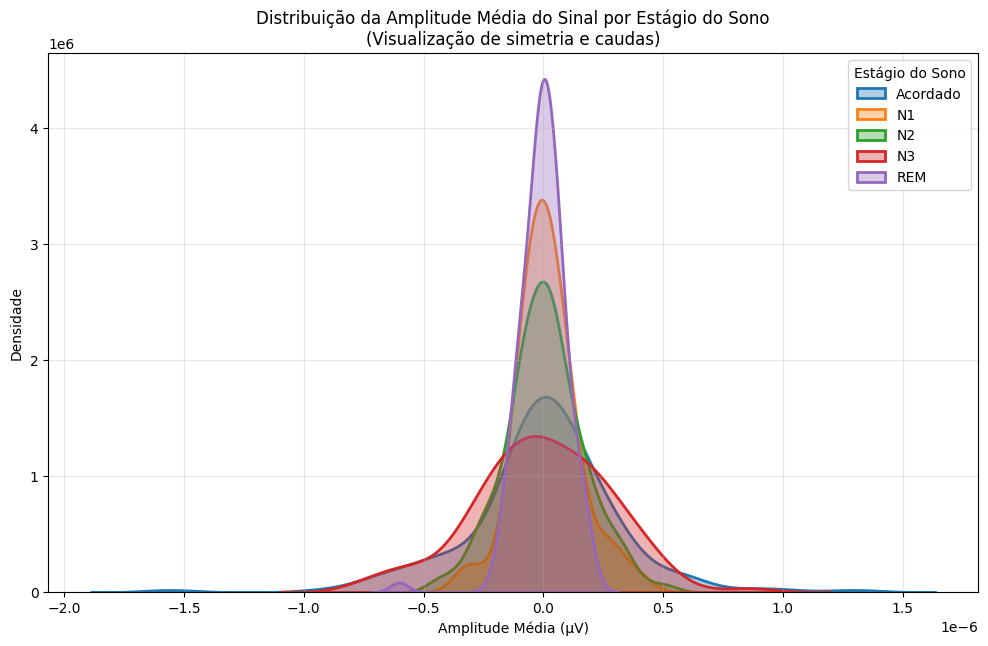

In [ ]:
plt.figure(figsize=(12, 7))

# Gráfico de densidade por estágio
for stage in ['Acordado', 'N1', 'N2', 'N3','REM']:
    subset = df[df['estagio'] == stage]
    sns.kdeplot(subset['media'], label=stage, fill=True, alpha=0.35, linewidth=2)

plt.title('Distribuição da Amplitude Média do Sinal por Estágio do Sono\n(Visualização de simetria e caudas)')
plt.xlabel('Amplitude Média (µV)')
plt.ylabel('Densidade')
plt.legend(title='Estágio do Sono')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import skew

# 'Acordado', 'N1', 'N2', 'N3' ou 'REM'
estagio_escolhido = 'N3'

fs = 100
t = np.arange(0, 30, 1/fs)

if estagio_escolhido == 'Acordado':
    # Alta frequência (Beta), amplitude baixa, mas MUITO ruído (transientes negativos)
    onda = 10 * np.sin(2 * np.pi * 20.0 * t)
    ruido = 15 * np.random.normal(loc=-0.8, scale=2, size=len(t)) # loc negativo simula artefatos

elif estagio_escolhido == 'N1':
    # Transição: Ondas Theta (4-7Hz), ruído moderado
    onda = 15 * np.sin(2 * np.pi * 6.0 * t)
    ruido = 10 * np.random.normal(loc=-0.2, scale=1.5, size=len(t))

elif estagio_escolhido == 'N2':
    # Ondas Sigma (Sleep Spindles) 12-14Hz misturadas com Theta
    onda = 20 * np.sin(2 * np.pi * 13.0 * t)
    ruido = 8 * np.random.normal(loc=0.3, scale=1, size=len(t))

elif estagio_escolhido == 'N3':
    # Ondas Delta (0.5-4Hz), alta amplitude, sinal limpo e rítmico
    onda = 50 * np.sin(2 * np.pi * 1.5 * t)
    ruido = 5 * np.random.normal(loc=0.5, scale=1, size=len(t))

elif estagio_escolhido == 'REM':
    # Similar ao Acordado, mas sem o ruído muscular (atonia), sinal mais centralizado
    onda = 12 * np.sin(2 * np.pi * 15.0 * t)
    ruido = 7 * np.random.normal(loc=0.1, scale=1, size=len(t))

sinal = onda + ruido

# Cálculos
media_amp = np.mean(sinal)
mediana_amp = np.median(sinal)
assimetria_valor = skew(sinal)

print(f"--- Análise: Época Única de {estagio_escolhido} ---")
print(f"Média da Amplitude:   {media_amp:.15f}")
print(f"Mediana da Amplitude: {mediana_amp:.15f}")
print(f"Valor da Assimetria:  {assimetria_valor:.15f}")

print("\n--- Resultado da Classificação ---")
if assimetria_valor > 0:
    print("Assimetria Positiva (Cauda à Direita)")
elif assimetria_valor < 0:
    print("Assimetria Negativa (Cauda à Esquerda)")
else:
    print("Simétrica")

print("\n--- Validação (Média vs Mediana) ---")
if (assimetria_valor > 0 and media_amp > mediana_amp) or (assimetria_valor < 0 and media_amp < mediana_amp):
    print("A regra coincide com o Skewness.")
else:
    print("[DIVERGÊNCIA] Caso especial: O Skewness prevalece sobre a Mediana.")

--- Análise: Época Única de N3 ---
Média da Amplitude:   2.509255982516372
Mediana da Amplitude: 2.156124352172224
Valor da Assimetria:  0.003985385498597

--- Resultado da Classificação ---
Assimetria Positiva (Cauda à Direita)

--- Validação (Média vs Mediana) ---
A regra coincide com o Skewness.


Ao observarmos os gráficos de densidade (KDE), a diferença entre os estágios torna-se evidente pela largura (dispersão) e pelo comportamento das caudas das curvas:

- Amplitude e Dispersão (N3 vs. N1): A curva do estágio N3 é a mais larga e achatada do gráfico. Isso ocorre devido à alta voltagem das ondas Delta, que aumenta a variância do sinal. Por isso, visualmente, o N3 se estende mais para as extremidades (esquerda e direita) do que o N1, que possui baixa voltagem e uma curva estreita.

- Assimetria e Transientes (Acordado e N1): A curva azul (Acordado) é a que apresenta a maior extensão para a esquerda no eixo X, confirmando a assimetria negativa (-0,128). Esse "rastro" representa quedas bruscas de voltagem (transientes) típicas da vigília. O N1 também apresenta assimetria negativa (-0,024), indicando que, embora seja um sono leve e de baixa amplitude, ele ainda carrega a instabilidade característica da transição do sono.

- Transição para a Simetria: À medida que o sono se estabiliza no N2 (0,060) e N3 (0,179), os valores de assimetria tornam-se positivos. Isso prova que o sinal deixa de ser dominado por quedas desordenadas e passa a ser composto por oscilações mais rítmicas e organizadas.

## Relações Entre Variáveis, Correlação e Causalidade
Existe forte associação entre potência delta alta e o estágio N3. No entanto, essa correlação não implica causalidade direta: a potência delta (medida quantitativa que mede a intensidade do sono profundo) não "causa" o N3, nem o N3 "causa" a potência. Tanto a potência delta quanto o estágio N3 são manifestações do mesmo estado fisiológico (atividade lenta de ondas durante o sono profundo). Trata-se de uma associação fisiológica esperada, e não de uma relação de causa e efeito.

Não foram identificadas correlações espúrias evidentes (falsas relações causais), pois todas as _features_ foram extraídas do mesmo sinal EEG no mesmo intervalo temporal. Contudo, para garantir a robustez de um futuro classificador, deve-se considerar a variabilidade inter-paciente, evitando que características individuais de uma noite específica sejam interpretadas como regras universais do sono.

## Probabilidade Condicional
Um exemplo prático de probabilidade condicional aplicável à classificação automática de estágios do sono é:
“Dado que a potência delta está acima da mediana, qual é a probabilidade de a época ser classificada como N3?”

Essa mediana refere-se à mediana da variável "potencia_delta" calculada sobre as 841 épocas da base. Esse questionamento é relevante porque, durante o aprofundamento do sono, o cérebro começa a gerar ondas lentas (delta) antes mesmo de se atingir a porcentagem necessária de atividade delta para que uma época seja oficialmente classificada como estágio N3. Como consequência, o polissonograma pode apresentar alta densidade de ondas delta enquanto o técnico ainda classifica a época como N2.

In [ ]:
# Cálculo entre probabilidade condicional de N3 e potência delta alta e probabilidade geral de N3 na base

df = pd.read_csv("dados/brutos/dados_epocas.csv")

# Calcula a mediana da potência delta
mediana_delta = df['potencia_delta'].median()

# Cria máscara: épocas onde potência delta > mediana
alta_delta = df['potencia_delta'] > mediana_delta

# Probabilidade condicional P(N3 | delta alta)
p_n3_condicional = df[alta_delta]['estagio'].value_counts(normalize=True).get('N3', 0)

# Probabilidade geral de N3 na base de dados
p_n3_geral = (df['estagio'] == 'N3').mean()

# Exibição dos resultados
print(f"Mediana da potência delta = {mediana_delta:.2e}")
print(f"Número de épocas com delta acima da mediana = {alta_delta.sum()}")
print(f"\nP(N3 | delta > mediana) = {p_n3_condicional:.4f} ({p_n3_condicional*100:.1f}%)")
print(f"P(N3) geral na base = {p_n3_geral:.4f} ({p_n3_geral*100:.1f}%)")
print(f"Razão = {p_n3_condicional / p_n3_geral:.2f} vezes maior")

Mediana da potência delta = 2.31e-10
Número de épocas com delta acima da mediana = 420

P(N3 | delta > mediana) = 0.5238 (52.4%)
P(N3) geral na base = 0.2616 (26.2%)
Razão = 2.00 vezes maior


No caso analisado, quando a potência delta está acima da mediana, a probabilidade de a época ser N3 é de 0,524 (52,4%). Esse valor é significativamente maior do que a probabilidade geral de ocorrência de N3 em toda a base, que é de apenas 0,262 (26,2%), ou seja, aproximadamente duas vezes maior.

Essa diferença demonstra que a potência delta é uma _feature_ discriminante importante para identificar o sono profundo, pois ela consegue separar o estágio N3 dos demais estágios com boa eficiência, mesmo antes da classificação oficial ser atribuída.

## Validação da Probabilidade Condicional
O Boxplot abaixo permite validar a aplicação da probabilidade condicional para a classificação automática:

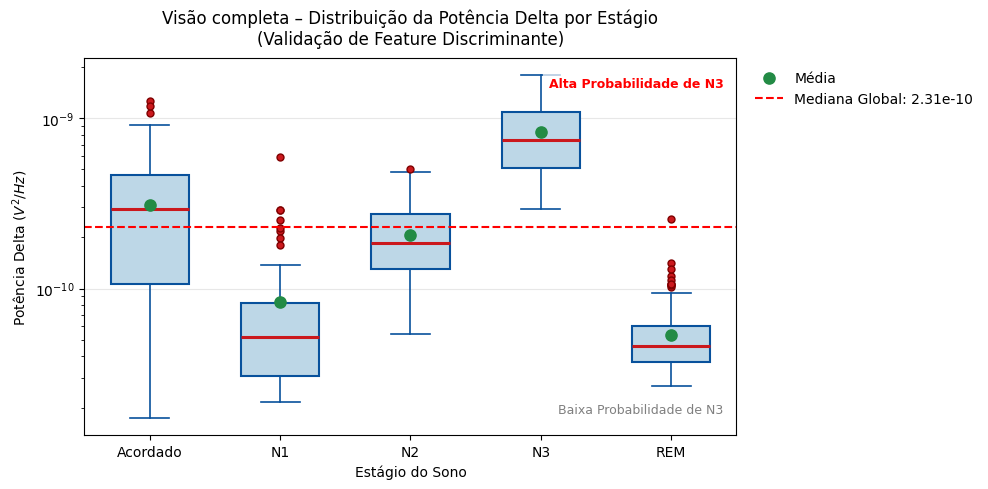

In [ ]:
estagios_ordenados = sorted(df['estagio'].unique())
dados_por_estagio = [df[df['estagio'] == s]['potencia_delta'].dropna().values for s in estagios_ordenados]
medias_por_estagio = [np.mean(d) for d in dados_por_estagio]
mediana_global = df['potencia_delta'].median()

estilo = dict(
    tick_labels=estagios_ordenados,
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor='#bdd7e7', edgecolor='#08519c', linewidth=1.5),
    medianprops=dict(color='#cb181d', linewidth=2.2),
    whiskerprops=dict(color='#08519c', linewidth=1.2),
    capprops=dict(color='#08519c', linewidth=1.2),
    flierprops=dict(marker='o', markerfacecolor='#cb181d', markeredgecolor='#7f0000', markersize=5),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(dados_por_estagio, **estilo)
ax.scatter(range(1, len(estagios_ordenados)+1), medias_por_estagio,
           color='#238b45', s=65, zorder=3, label='Média')
ax.axhline(mediana_global, color='red', linestyle='--', linewidth=1.5,
           label=f'Mediana Global: {mediana_global:.2e}')

ax.text(0.98, 0.95, 'Alta Probabilidade de N3', transform=ax.transAxes,
        color='red', fontweight='bold', fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
ax.text(0.98, 0.05, 'Baixa Probabilidade de N3', transform=ax.transAxes,
        color='gray', fontsize=9,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

ax.set_yscale('log')
ax.set_title('Visão completa – Distribuição da Potência Delta por Estágio\n(Validação de Feature Discriminante)', pad=10)
ax.set_ylabel('Potência Delta ($V^2/Hz$)')
ax.set_xlabel('Estágio do Sono')

# Legenda posicionada fora da área do gráfico, à direita
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)

ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

A visualização do Boxplot permite validar a aplicação da probabilidade condicional e identificar como os padrões estatísticos contribuem para a classificação automática:

- Observa-se que praticamente 100% das épocas de N3 estão posicionadas acima da linha da mediana global. Isso confirma que a probabilidade condicional $P(N3 \mid \text{Delta} > \text{Mediana})$ é alta, tornando a potência delta a característica mais robusta para identificar o sono reparador.

- Embora os estágios N1 e REM estejam claramente abaixo da linha vermelha (facilitando sua separação do N3), suas "caixas" no gráfico ocupam quase o mesmo intervalo de valores no eixo Y. Essa sobreposição visual indica que a Potência Delta, sozinha, é insuficiente para distinguir o sono leve do sono dos sonhos, o que justifica a necessidade de combinar outras variáveis (como a assimetria ou Alpha) para reduzir a incerteza do modelo classificador.

- O estágio Acordado apresenta a maior dispersão. Os pontos acima dos bigodes (_outliers_) refletem os picos irregulares e transitórios de voltagem que ultrapassam a barreira da mediana e se aproximam do nível do sono profundo (N3). Se o modelo classificador considerar apenas um desses pontos isoladamente, poderá classificar erroneamente o paciente como estando em sono profundo quando, na realidade, ele apenas realizou um movimento corporal. Em outras palavras, diferente dos estágios de sono, que possuem um comportamento mais rítmico e contido, o estado desperto é marcado por picos súbitos (transientes) que o modelo precisará aprender a ignorar para não confundir com o sono verdadeiro.

- O estágio N2 atua como um divisor estatístico, pois sua mediana coincide com a mediana global do sinal. Essa característica é coerente com o fato de o N2 ser o estágio “padrão” ou “médio”, uma vez que ocupa a maior parte do tempo de sono, conforme observado na análise da arquitetura do sono. Por estar em uma zona de transição, esse estágio representa o ponto de maior ambiguidade para o classificador, exigindo contexto temporal para uma decisão precisa.

Esse contexto temporal refere-se à sequencialidade biológica do sono. Diferente de uma imagem isolada, uma época de EEG faz parte de um ciclo. Para resolver a ambiguidade do N2, o sistema automático pode utilizar informações das épocas vizinhas: se as janelas anteriores indicam uma progressão para o sono profundo, o valor 'médio' do N2 é interpretado como uma entrada no estágio N3. Essa análise de séries temporais compensa a sobreposição estatística observada no boxplot.

Além disso, diferente da sobreposição crítica entre N1 e REM, os estágios Acordado e N3 oferecem pistas visuais e estatísticas muito distintas. Enquanto o N3 é identificado pelo valor absoluto elevado, a Vigília é identificada pela sua variabilidade e picos, onde o cérebro tem uma explosão de voltagem, geralmente causada por movimentos do paciente, piscadas de olhos ou micro-despertares. Portanto, o desafio real do sistema automático será o refinamento da zona de baixa potência, onde o sono leve e o sono REM se confundem estatisticamente.

## Matriz de Correlação

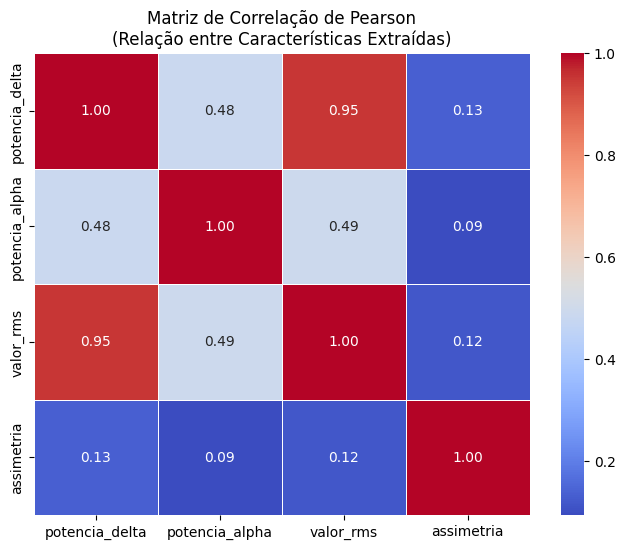

In [ ]:
# Selecionando apenas as colunas numéricas para a correlação
colunas_features = ['potencia_delta', 'potencia_alpha', 'valor_rms', 'assimetria']
corr = df[colunas_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação de Pearson\n(Relação entre Características Extraídas)')
plt.show()

Os atributos `valor_rms` e `potencia_delta` apresentam correlação positiva alta ($r = 0.95$), o que é fisiologicamente coerente. Essa relação confirma que, no sinal de EEG, a maior parte da energia total (medida pelo RMS) é proveniente das frequências baixas (delta). Ademais, ondas de alta amplitude ocorrem justamente na banda delta durante o sono profundo.

Por outro lado, a assimetria apresenta correlação baixa (independência linear) em relação às variáveis de potência ($r < 0.15$). Para o modelo classificador, a assimetria constitui uma variável crítica para discriminar estados de instabilidade (vigília) de estados de sincronização (N3), conforme observado anteriormente na análise dos boxplots.

## Análise de Estabilidade da Amplitude dos Estágios
O gráfico de barras abaixo revela o comportamento energético dos estágios através da média e do desvio padrão.

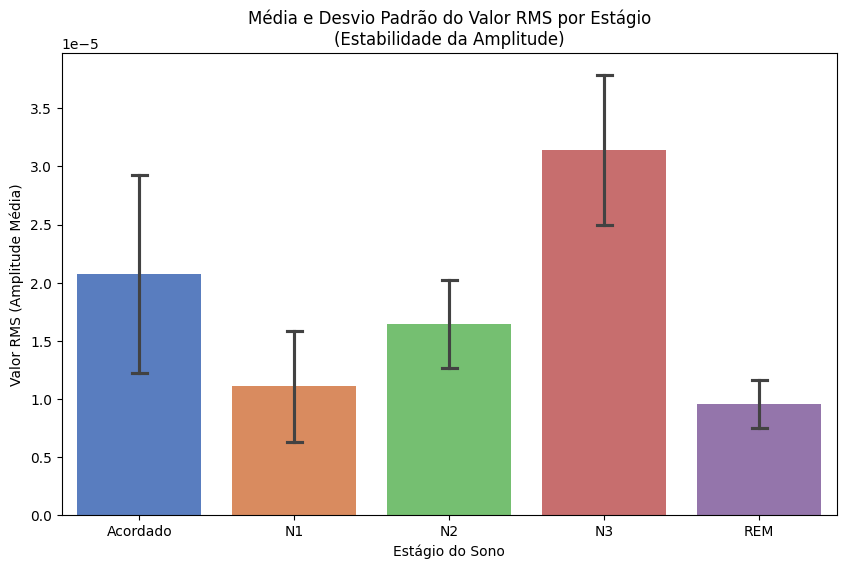

In [ ]:
plt.figure(figsize=(10, 6))
# O 'capsize' adiciona as barras horizontais no topo do erro
sns.barplot(data=df, x='estagio', y='valor_rms', hue='estagio', capsize=.1, palette='muted', errorbar='sd')
plt.title('Média e Desvio Padrão do Valor RMS por Estágio\n(Estabilidade da Amplitude)')
plt.ylabel('Valor RMS (Amplitude Média)')
plt.xlabel('Estágio do Sono')
plt.show()

## Interpretação do Gráfico de Barras
Ao analisar o gráfico de barras, é fundamental observar a relação entre a magnitude da energia (altura da barra) e a dispersão dos dados (haste de erro). Enquanto a média nos indica o 'volume' elétrico do estágio, o desvio padrão nos revela a sua consistência.

- As barras representam as médias, enquanto as linhas pretas (haste de erro) representam os desvios padrão.

- O estágio N3 apresenta não apenas a maior média de amplitude, mas também uma barra de erro considerável, refletindo a intensidade das ondas delta. Isso reflete a natureza do sono profundo: um estado de alta energia mecânica, mas que não é uniforme. A grande variação mostra que o cérebro está produzindo disparos elétricos massivos, mas que oscilam em intensidade ao longo do tempo.

- O estágio REM, com barra de erro menor, é um estágio "previsível". Quase todas as épocas mantêm a mesma voltagem baixa, resultando em pouco 'erro' ou variação em relação à média.

In [ ]:
# Agrupando por estágio e calculando Média e Desvio Padrão
stats = df.groupby('estagio')['valor_rms'].agg(['mean', 'std']).reset_index()

# Calculando o Coeficiente de Variação (CV) em porcentagem
# Quanto menor o CV, mais "previsível" e estável é o estágio.
stats['CV (%)'] = (stats['std'] / stats['mean']) * 100

# Ordenando pelo CV para ver quem é o mais estável
stats = stats.sort_values(by='CV (%)')

print("Análise de Estabilidade e Previsibilidade por Estágio:")
print(stats[['estagio', 'mean', 'std', 'CV (%)']])


Análise de Estabilidade e Previsibilidade por Estágio:
    estagio      mean       std     CV (%)
3        N3  0.000031  0.000006  20.504126
4       REM  0.000010  0.000002  21.422579
2        N2  0.000016  0.000004  22.832417
0  Acordado  0.000021  0.000009  41.189319
1        N1  0.000011  0.000005  42.919065


Os dados confirmam que a estabilidade do sinal não depende da amplitude, mas sim da natureza do estágio do sono. Um estágio pode ser potente e apresentar alta variabilidade de amplitude (N3), devido à natureza pulsante e intensa das ondas delta, ou ser silencioso e extremamente estável (REM), onde a baixa voltagem se mantém constante. Isso demonstra que a previsibilidade do sinal é uma assinatura fisiológica independente da sua magnitude.

Ressalta-se que, no estágio N3, a instabilidade diz respeito à magnitude (ocorrência de ondas muito grandes ou simplesmente grandes), enquanto no estágio N1 a instabilidade refere-se ao estado (transição entre dormindo e acordando).

O grupo de estabilidade é composto pelos estágios N3, REM e N2, os quais apresentam os menores coeficientes de variação (CV), situados na faixa de 20% a 22%. Isso significa que, embora o N3 tenha amplitude aproximadamente três vezes maior que o REM, ambos são igualmente estáveis em seus respectivos níveis. Conclui-se que, uma vez que o paciente entra nesses estágios, o sinal de EEG mantém um padrão rítmico e previsível.

O grupo de instabilidade inclui os estágios Acordado e N1, que exibem coeficientes de variação muito elevados (acima de 41%), ou seja, o dobro da variação observada nos demais estágios. Conclui-se que o N1 é, estatisticamente, o estágio de sono mais instável. Isso confirma que o estágio N1 realmente oscila muito mais que o REM, apesar de ambos apresentarem médias de energia muito próximas (respectivamente, 0,000010 vs 0,000011).

Mesmo que o estágio N1 apresente desvio padrão levemente superior ao estágio REM, ambos mantêm médias de amplitude muito próximas e significativamente inferiores às do N3. A sobreposição das barras de erro demonstra que, em termos de RMS (energia), os estágios N1 e REM ocupam a mesma faixa de magnitude, o que confirma que a amplitude isolada não constitui um critério robusto para separá-los, sendo necessárias métricas baseadas em frequência ou forma de onda para uma classificação precisa. Ademais, o estágio N1 exibe maior instabilidade (barra de erro mais alta) por se tratar de um estágio de transição, enquanto o REM apresenta comportamento mais estável em baixa voltagem (barra de erro menor).

Conclui-se que N1 e REM são semelhantes quanto ao nível de energia (baixo), mas o N1 exibe maior variabilidade estatística que o REM. No estágio N1 (sono de transição), como o paciente está em um estado de alternância entre vigília e sono, o sinal de EEG oscila mais, ora se apresentando com amplitude muito baixa, ora com pequenos surtos de atividade. Essa “indecisão” do cérebro gera um desvio padrão mais elevado. Já no estágio REM (sono dos sonhos), o cérebro encontra-se em um estado de dessincronização específico e mantido; a voltagem é baixa, porém estável nessa faixa. A barra de erro curta indica que os valores de RMS no REM não se afastam muito da média.

# Ciclos e Estágios do Sono <font color="green">(Wendell)</font>

Além de avaliar a proporção global de cada estágio na base de dados, é imprescindível investigar a dinâmica temporal da arquitetura do sono. A literatura médica estabelece que o sono humano é um processo não-estacionário e cíclico, composto por sequências que duram, em média, 90 minutos. Durante a noite, a duração e a intensidade energética de cada estágio sofrem variações previsíveis de um ciclo para outro. Dessa forma, o objetivo desta etapa é fatiar o registro do sinal em janelas contínuas de 1h30 (5400 segundos). Essa abordagem nos permite analisar a distribuição interna das fases ciclo a ciclo, evidenciando as transições estatísticas e revelando como o domínio temporal de todos os estágios alternam do início ao fim da gravação.

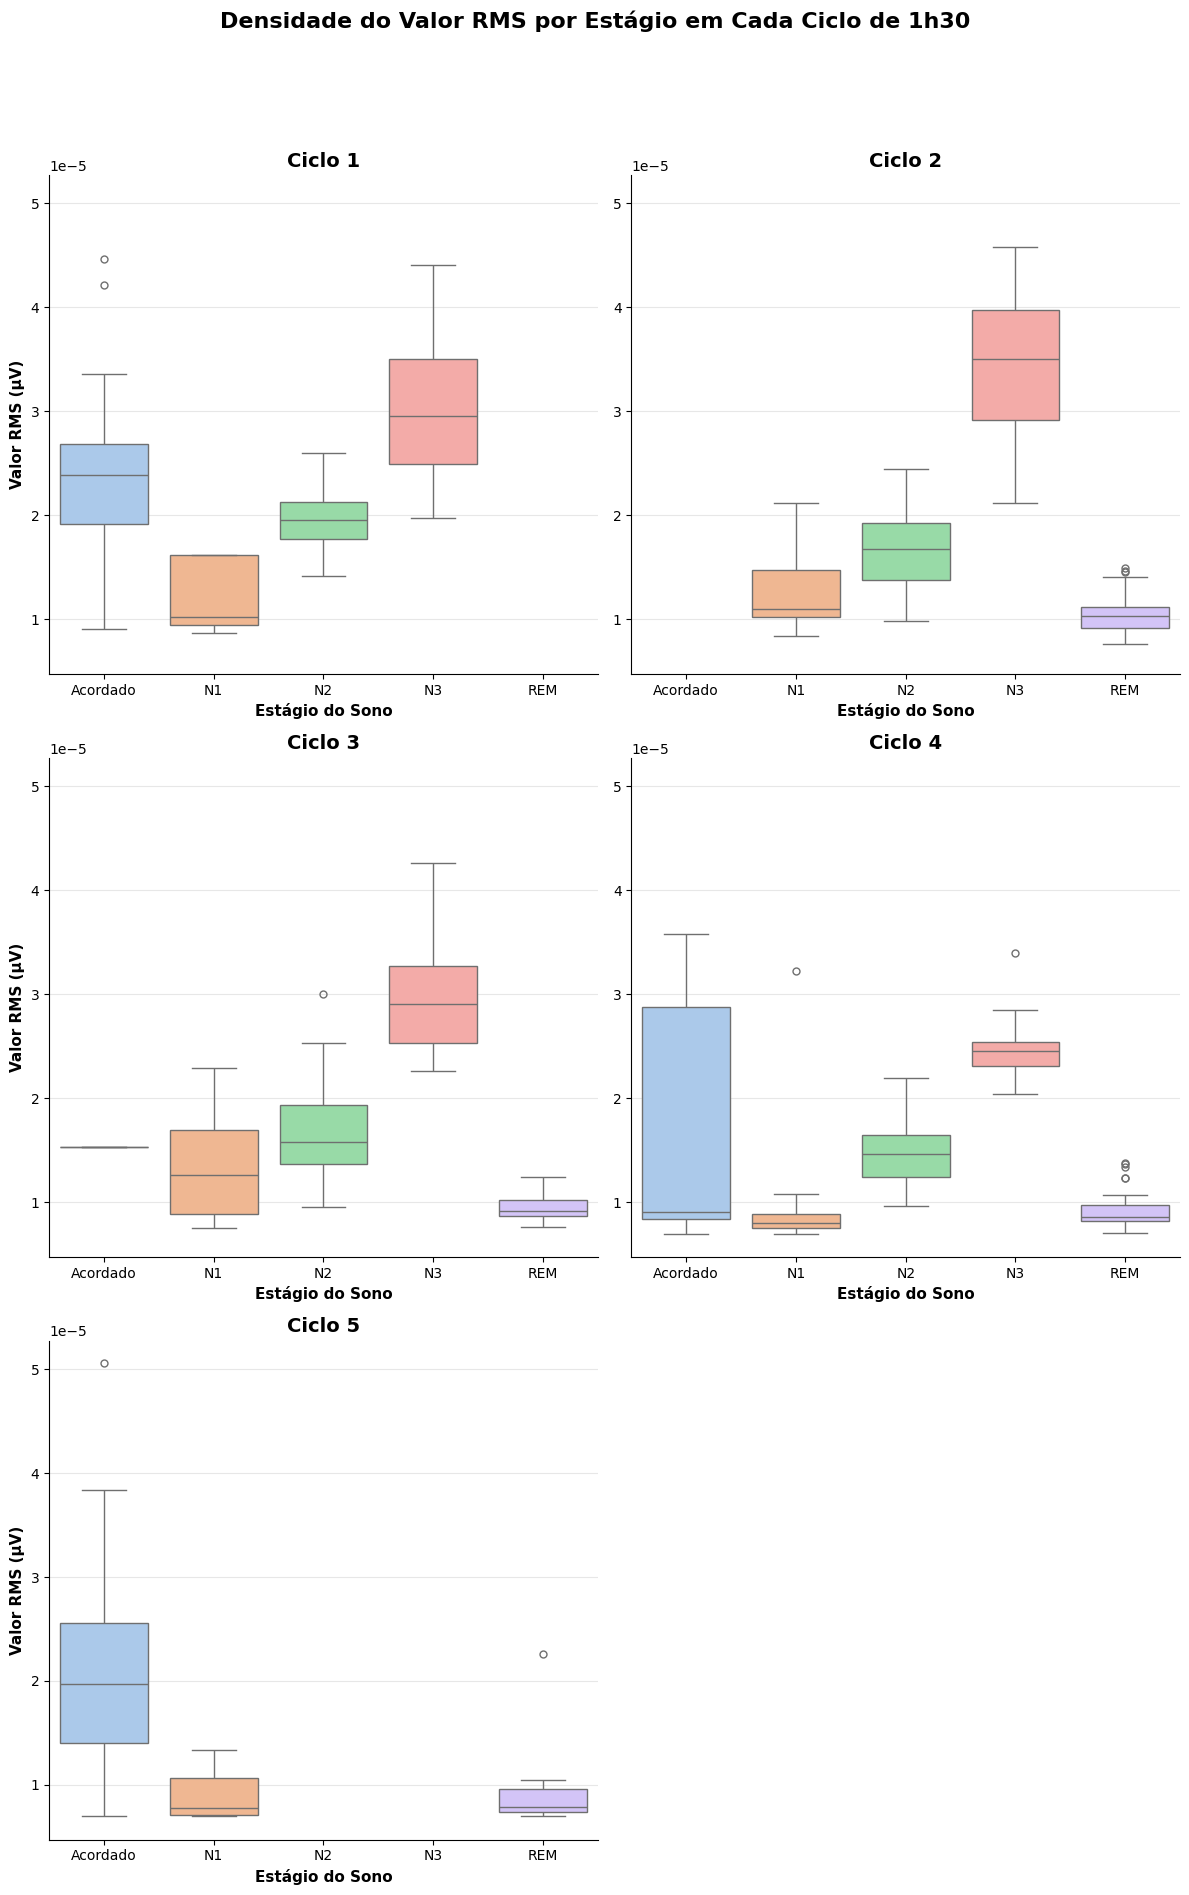

In [ ]:
df['tempo_relativo_s'] = df['inicio_epoca_s'] - df['inicio_epoca_s'].min()
df['ciclo_90min'] = (df['tempo_relativo_s'] // 5400) + 1
df['ciclo_nome'] = 'Ciclo ' + df['ciclo_90min'].astype(int).astype(str)


ordem_estagios = ['Acordado', 'N1', 'N2', 'N3', 'REM']

# Criando um FacetGrid (Subplots) aprimorado
g = sns.catplot(
    data=df,
    x='estagio',
    y='valor_rms',
    col='ciclo_nome',
    col_wrap=2,           # Máximo de 3 gráficos por linha
    kind='box',        # Troque para 'box' se preferir o Boxplot
    order=ordem_estagios,
    hue='estagio',
    palette='pastel',
    legend=False,
    # inner='quartile',
    height=6,             # AUMENTADO: Deixa cada subplot mais alto
    aspect=1.0,           # AJUSTADO: Proporção 1:1 (quadrada) para não achatar os violinos
    sharey=True,          # Mantém a mesma escala Y para comparação justa entre os ciclos
    sharex=False          # Permite que o eixo X seja tratado individualmente
)

# Ajustando o título principal
g.fig.suptitle('Densidade do Valor RMS por Estágio em Cada Ciclo de 1h30',
               y=1.05, fontsize=16, fontweight='bold')

# Loop para forçar as legendas e números em TODOS os subplots
for ax in g.axes.flatten():
    # Garante que os números apareçam em todos os eixos X e Y
    ax.tick_params(labelbottom=True, labelleft=True)

    # Define o nome dos eixos individualmente
    ax.set_xlabel("Estágio do Sono", fontsize=11, fontweight='bold')
    ax.set_ylabel("Valor RMS (µV)", fontsize=11, fontweight='bold')

    # Adiciona o grid de fundo
    ax.grid(True, alpha=0.3, axis='y')

# Melhora a fonte dos títulos de cada subplot (ex: "Ciclo 1")
g.set_titles(col_template="{col_name}", size=14, fontweight='bold')

plt.tight_layout()
plt.show()

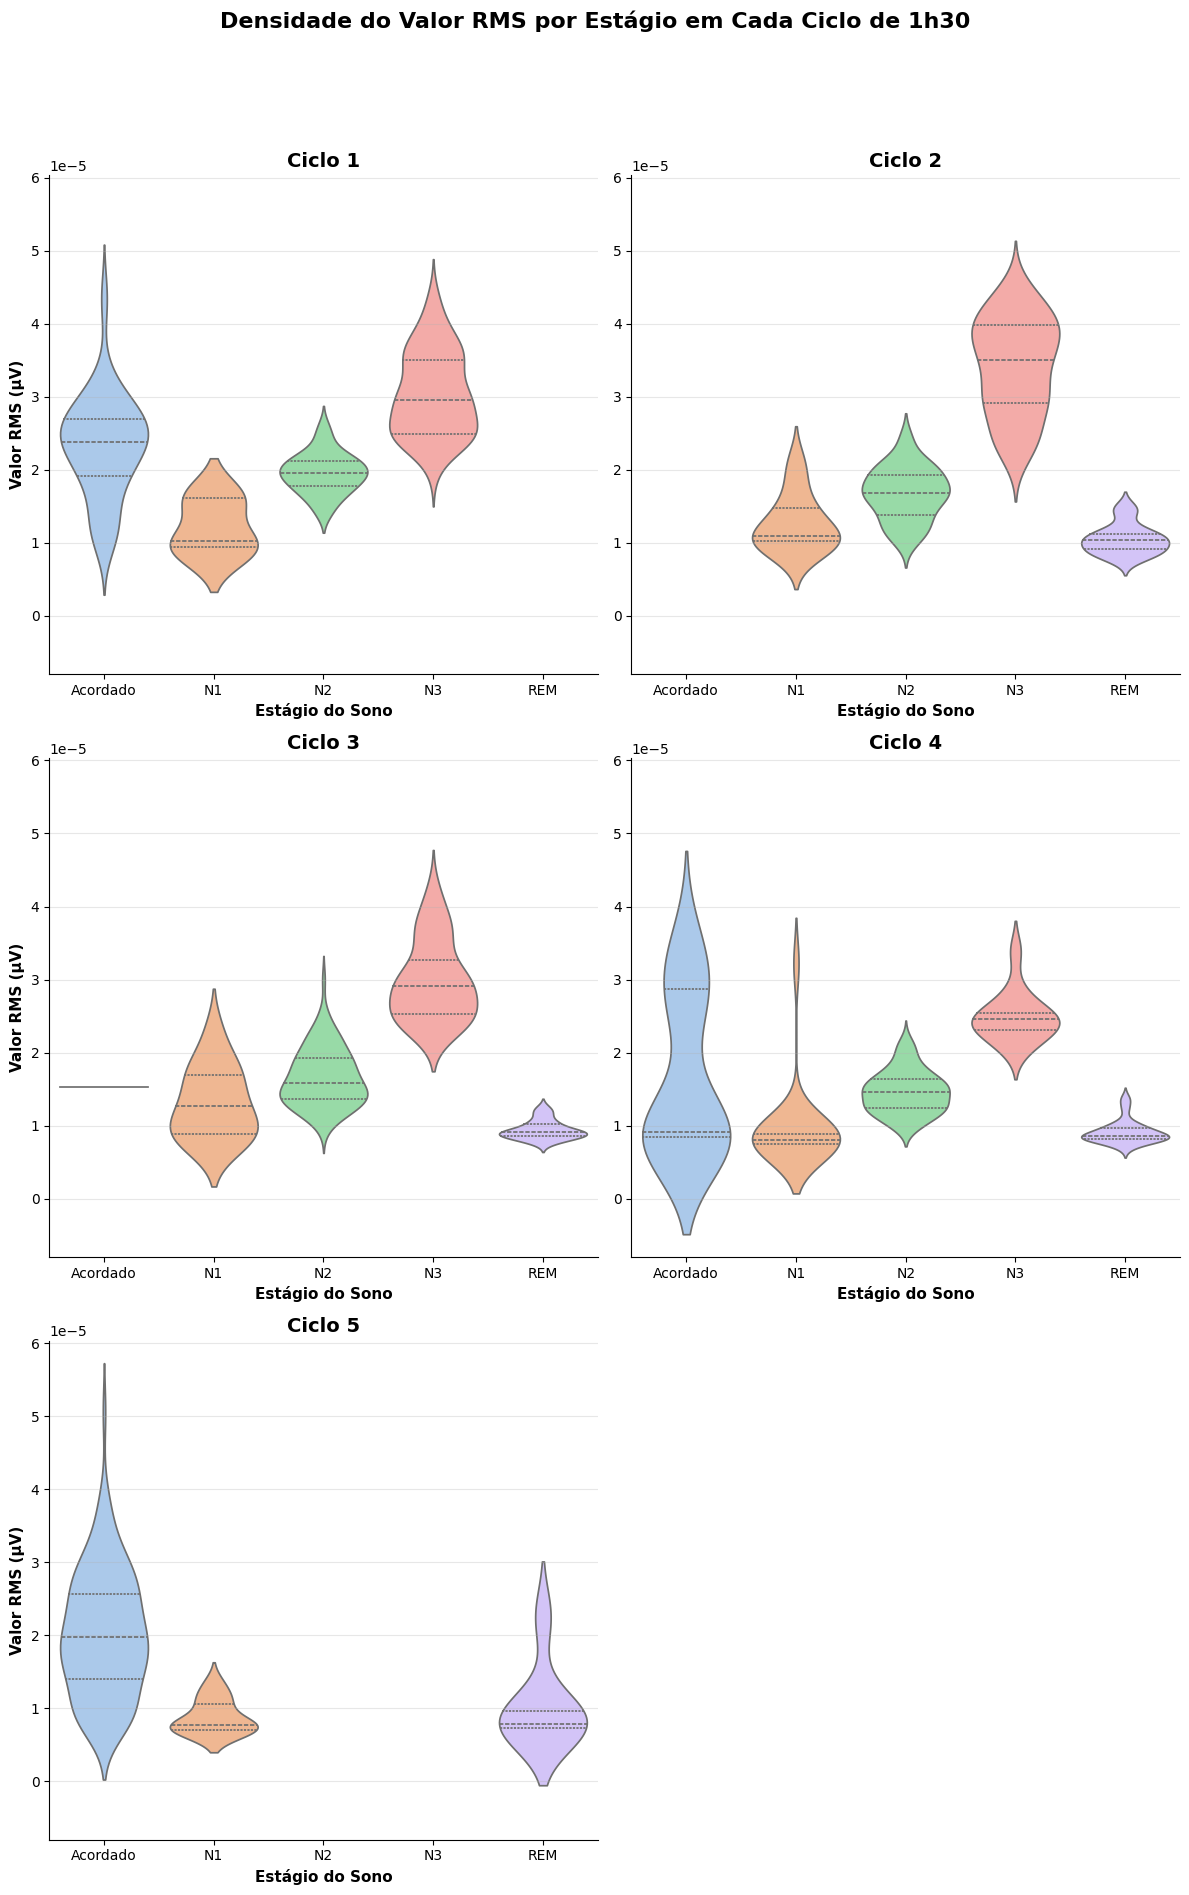

In [ ]:
ordem_estagios = ['Acordado', 'N1', 'N2', 'N3', 'REM']

# Criando um FacetGrid (Subplots) aprimorado
g = sns.catplot(
    data=df,
    x='estagio',
    y='valor_rms',
    col='ciclo_nome',
    col_wrap=2,           # Máximo de 3 gráficos por linha
    kind='violin',        # Troque para 'box' se preferir o Boxplot
    order=ordem_estagios,
    hue='estagio',
    palette='pastel',
    legend=False,
    inner='quartile',
    height=6,             # AUMENTADO: Deixa cada subplot mais alto
    aspect=1.0,           # AJUSTADO: Proporção 1:1 (quadrada) para não achatar os violinos
    sharey=True,          # Mantém a mesma escala Y para comparação justa entre os ciclos
    sharex=False          # Permite que o eixo X seja tratado individualmente
)

# Ajustando o título principal
g.fig.suptitle('Densidade do Valor RMS por Estágio em Cada Ciclo de 1h30',
               y=1.05, fontsize=16, fontweight='bold')

# Loop para forçar as legendas e números em TODOS os subplots
for ax in g.axes.flatten():
    # Garante que os números apareçam em todos os eixos X e Y
    ax.tick_params(labelbottom=True, labelleft=True)

    # Define o nome dos eixos individualmente
    ax.set_xlabel("Estágio do Sono", fontsize=11, fontweight='bold')
    ax.set_ylabel("Valor RMS (µV)", fontsize=11, fontweight='bold')

    # Adiciona o grid de fundo
    ax.grid(True, alpha=0.3, axis='y')

# Melhora a fonte dos títulos de cada subplot (ex: "Ciclo 1")
g.set_titles(col_template="{col_name}", size=14, fontweight='bold')

plt.tight_layout()
plt.show()

Ao analisarmos a distribuição temporal completa de um registro de polissonografia, fica evidente que o domínio de cada estágio se altera substancialmente do início ao fim da gravação. Nas fases iniciais e no meio da noite, o corpo dá prioridade absoluta ao estágio N3, correspondente ao sono profundo, pois o cérebro necessita da alta sincronia neuronal associada às ondas lentas para realizar a recuperação física. Paralelamente a isso, o estágio N2 consolida-se como a fase mais frequente, atuando como uma verdadeira ponte de transição constante que interliga as demais fases. Conforme o registro avança para a fragmentação final, a necessidade fisiológica de sono profundo já foi saciada e ele praticamente desaparece. Em seu lugar, ocorre uma intensificação progressiva do sono REM, voltado ao reequilíbrio emocional, juntamente com o aumento das fases transicionais e saltos diretos para o estado de vigília, o que reflete a prontidão do cérebro para o despertar.

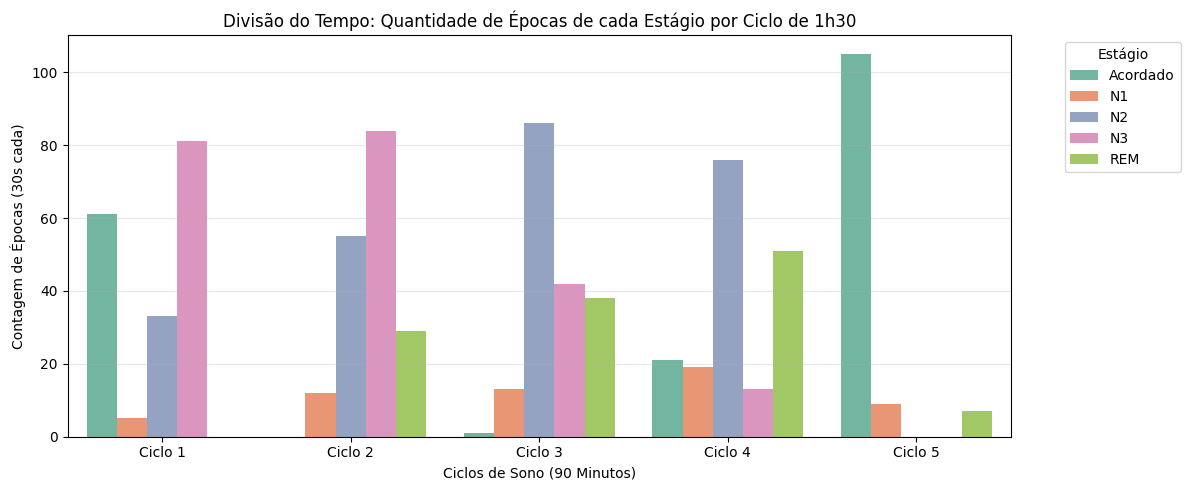

In [ ]:
# Contagem da divisão de tempo em cada fase por Ciclo
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='ciclo_nome', hue='estagio', hue_order=ordem_estagios, palette='Set2')
plt.title('Divisão do Tempo: Quantidade de Épocas de cada Estágio por Ciclo de 1h30')
plt.ylabel('Contagem de Épocas (30s cada)')
plt.xlabel('Ciclos de Sono (90 Minutos)')
plt.legend(title='Estágio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Análise de Agrupamento e Espaço de Características <font color="blue">(Ícaro)</font>
Realiza-se o cruzamento entre a Potência Delta (que mensura a magnitude e a sincronia) e a Assimetria (que avalia a morfologia e a instabilidade). Esse cruzamento é o que melhor separa o N3 da Vigília.

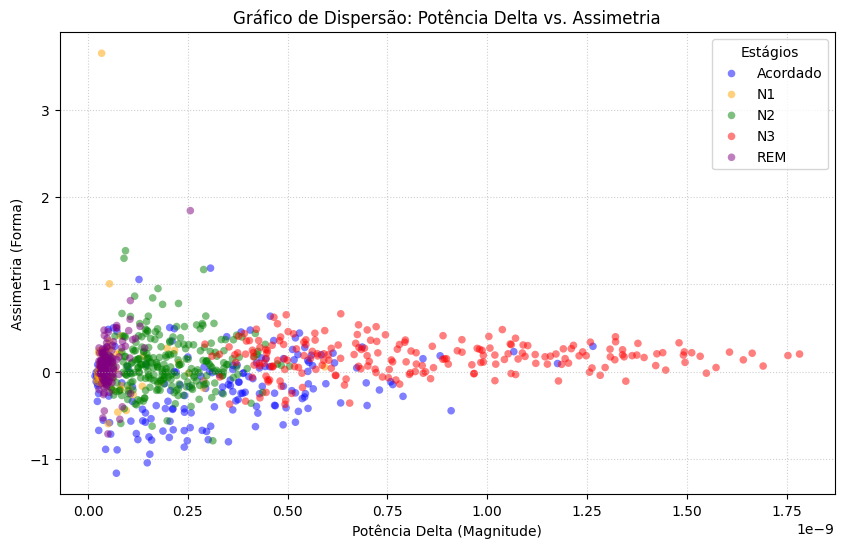

In [ ]:
# Definir as cores para cada estágio
cores_estagios = {
    'Acordado': 'blue',
    'N1': 'orange',
    'N2': 'green',
    'N3': 'red',
    'REM': 'purple'
}

plt.figure(figsize=(10, 6))

# 2. Plotar cada estágio separadamente para criar a legenda automática
for estagio, cor in cores_estagios.items():
    # Filtra o dataframe para o estágio atual
    dados_estagio = df[df['estagio'] == estagio]

    plt.scatter(
        dados_estagio['potencia_delta'],
        dados_estagio['assimetria'],
        label=estagio,
        color=cor,
        alpha=0.5,     # Transparência para ver sobreposição
        edgecolors='none',
        s=30           # Tamanho dos pontos
    )

# 3. Formatação do gráfico
plt.title('Gráfico de Dispersão: Potência Delta vs. Assimetria')
plt.xlabel('Potência Delta (Magnitude)')
plt.ylabel('Assimetria (Forma)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Estágios')

plt.show()

## Interpretação do Gráfico de Dispersão

- Observa-se que o estágio N3 tende a apresentar maior concentração de pontos à direita do gráfico (alta potência delta), distanciando-se dos estágios REM e N1. Em outras palavras, durante o sono N3, os neurônios entram em um estado de sincronia profunda, gerando ondas lentas de alta voltagem. Como a potência é proporcional ao quadrado da amplitude ($P = kA^2$), qualquer aumento na altura das ondas delta desloca os pontos do N3 consideravelmente para a direita no eixo X.

- Os pontos correspondentes aos estágios N1 e REM aparecem misturados no canto esquerdo. Essa sobreposição evidencia visualmente que a amplitude isoladamente não separa esses dois estágios, sendo necessárias ao classificador mais variáveis do que apenas essas duas para uma decisão precisa.

- Pontos do estágio "Acordado" aparecem dispersos em regiões inesperadas. Esse fato justifica o uso da assimetria como tentativa de identificar esses casos que a potência delta isoladamente confunde.

- Observa-se, ainda, que os pontos correspondentes ao estágio N2 atuam como uma “ponte” entre os pontos de baixa energia (à esquerda) e os de alta energia (N3). Esse comportamento reforça a ideia de que o N2 constitui um estágio intermediário de transição.

- O estágio REM é caracterizado por um sinal dessincronizado de baixa amplitude. Essa dessincronização ocorre porque o cérebro atinge um estado de alta atividade, voltado ao processamento de memórias, emoções e cenários complexos (sonhos), de modo muito semelhante ao estado de vigília. Para realizar esse processamento, os neurônios precisam disparar de forma independente e específica, sem um ritmo comum. A dessincronização neuronal é, portanto, necessária para o processamento complexo dos sonhos. A baixa amplitude observada no EEG é a consequência elétrica visível de que milhões de neurônios trabalham de forma independente, e não em sincronia, como ocorre no estágio N3.

### Relação Entre Sincronia e Amplitude Resumida

- Sincronia (N3) – Alta Amplitude: quando milhares de neurônios disparam juntos, a soma de suas correntes elétricas cria um pico grande (onda lenta).

- Dessincronização (REM) – Baixa Amplitude: quando os neurônios disparam de forma aleatória e independente, os sinais elétricos anulam-se ou sobrepõem-se de maneira caótica. Como não há soma coordenada das forças, o resultado no EEG é uma onda rápida e de baixa voltagem.

## Análise da Evolução dos Ciclos de Sono

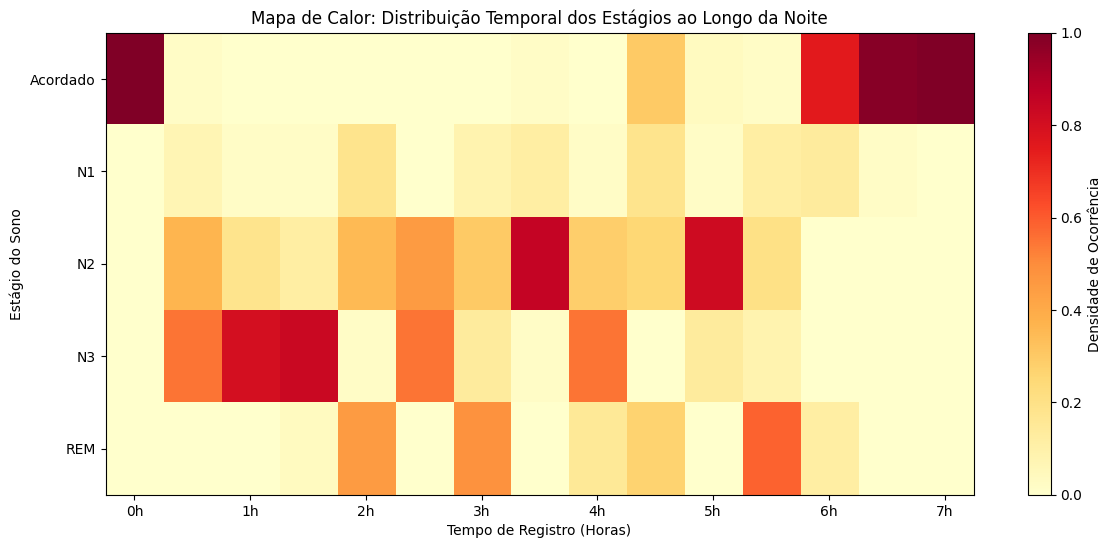

In [ ]:
# Dividir a noite em janelas de 30 minutos
# para ver a densidade de cada estágio ao longo do tempo.
df['janela_tempo'] = df.index // 60  # Agrupa cada 60 épocas (aprox. 30 min)

# Criar uma tabela cruzada com a contagem de estágios por janela
heatmap_data = df.groupby(['estagio', 'janela_tempo']).size().unstack(fill_value=0)

# Normalizar por coluna para ver a % de cada estágio naquele horário
heatmap_data_norm = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)

# Plotar o mapa de calor
plt.figure(figsize=(14, 6))
im = plt.imshow(heatmap_data_norm, cmap='YlOrRd', aspect='auto')

# Configurar eixos
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xticks(range(0, heatmap_data.shape[1], 2), [f'{i//2}h' for i in range(0, heatmap_data.shape[1], 2)])

plt.colorbar(im, label='Densidade de Ocorrência')
plt.title('Mapa de Calor: Distribuição Temporal dos Estágios ao Longo da Noite')
plt.ylabel('Estágio do Sono')
plt.xlabel('Tempo de Registro (Horas)')

plt.show()

## Interpretação do Mapa de Calor Temporal

- Observa-se que, logo após o adormecimento, o paciente percorre os estágios N1 e N2 até atingir o N3 no primeiro ciclo, conforme também ilustrado no gráfico “Divisão do Tempo: Quantidade de Épocas de cada Estágio por Ciclo de 1h30”. No primeiro ciclo, o estágio N3 costuma ser o mais longo, o que confirma que o cérebro prioriza o sono profundo logo no início da noite.

- Verifica-se, ainda, que as manchas vermelhas correspondentes aos estágios REM e Acordado tornam-se mais intensas a partir da quinta ou sexta hora de registro. Esse padrão explica por que os sonhos (REM) e os despertares breves (Acordado) são mais frequentes próximos ao amanhecer.

- O estágio N2 aparece distribuído ao longo de praticamente todo o gráfico (cor laranja/amarelo constante). Isso confirma que ele é o estágio intermediário da noite, servindo de transição para todos os outros estágios.

- O estágio N1, por sua vez, manifesta-se em tom amarelo claro e de forma dispersa, sem concentração em horário específico. Isso reforça o que os dados numéricos já indicavam. Trata-se de um estágio instável (CV = 42,9%), pois o estado biológico em si é transitório e imprevisível, ocorrendo em momentos aleatórios de transição. Esse comportamento explica por que, no mapa de calor, o N1 nunca forma blocos sólidos de cor, aparecendo sempre como eventos esparsos e breves.

Conclui-se que estágios de alta estabilidade estatística e magnitude, como o N3, concentram-se no início da noite, enquanto estágios de menor energia e maior instabilidade, como o REM e o Acordado, tornam-se predominantes conforme o despertar se aproxima.

Para o classificador, isso valida a inclusão da variável 'tempo decorrido' como um forte preditor. A probabilidade de um bloco de 30s ser N3 cai drasticamente após a 4ª hora de sono, facilitando a decisão do modelo.

## Perfil Temporal do Sono (Hipnograma)
O hipnograma é um gráfico que representa os estágios do sono em função do tempo. Ele permite visualizar a transição entre os estágios e a ocorrência dos ciclos de sono. Além disso, ele permite validar visualmente as tendências observadas no mapa de calor, como a concentração de sono profundo (N3) no início do registro e o aumento da fragmentação e do sono REM nas horas finais.

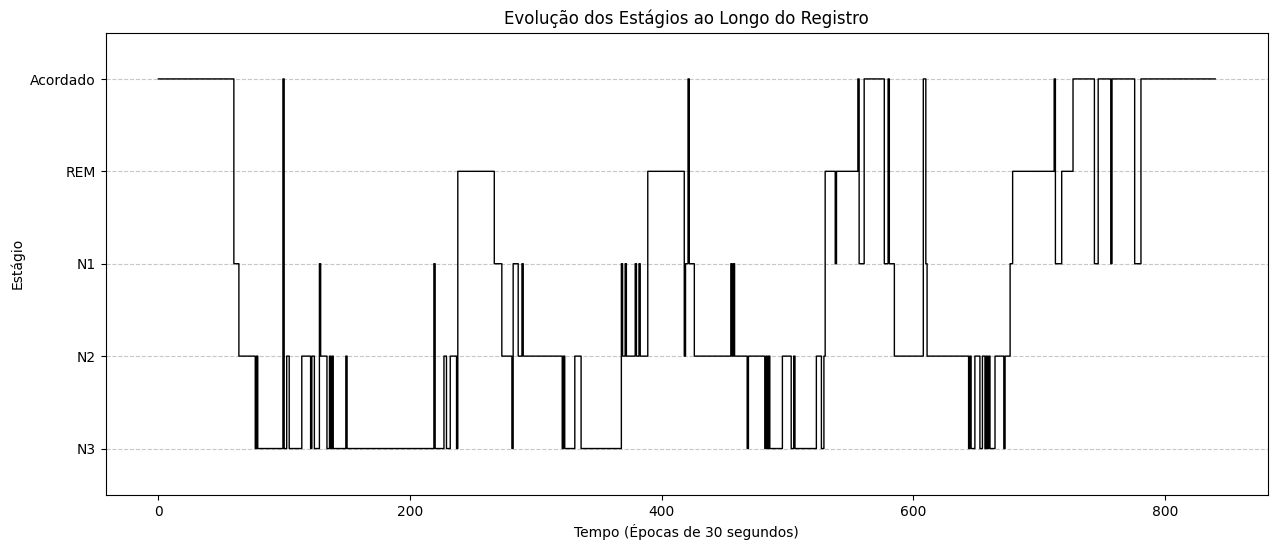

In [ ]:
# Mapear estágios para valores numéricos (ordem fisiológica comum)
mapa_niveis = {
    'Acordado': 4,
    'REM': 3,
    'N1': 2,
    'N2': 1,
    'N3': 0
}

# Criar coluna numérica para o gráfico
df['nivel_estagio'] = df['estagio'].map(mapa_niveis)

# Criar o gráfico
plt.figure(figsize=(15, 6))

# Plotar a linha em degraus
plt.step(df.index, df['nivel_estagio'], where='post', color='black', linewidth=1)

# Customizar o eixo Y com os nomes dos estágios
plt.yticks(list(mapa_niveis.values()), list(mapa_niveis.keys()))

# Formatação
plt.title('Evolução dos Estágios ao Longo do Registro')
plt.xlabel('Tempo (Épocas de 30 segundos)')
plt.ylabel('Estágio')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.ylim(-0.5, 4.5)

plt.show()

## Interpretação do Hipnograma

Enquanto o Mapa de Calor sintetiza a densidade dos estágios, o Hipnograma revela a transição exata entre eles, evidenciando que o sono não é um estado estático, mas uma "escada" fisiológica que o cérebro percorre em ciclos.

- Observa-se que as transições para o estágio N3 concentram-se na primeira metade do registro. Embora o sinal EEG dentro do N3 seja estatisticamente o mais estável (CV ≈ 20%), o estado de sono profundo é frequentemente interrompido por oscilações para o N2 ou breves despertares. Esses cenários de fragmentação ocorrem durante toda a noite, mas tornam-se críticos no final, onde o sono perde sua regularidade com trocas rápidas e sucessivas entre N1 e Acordado. Essa instabilidade visual, somada ao alto coeficiente de variação (CV > 40%), confirma para o modelo classificador que a previsibilidade do sono diminui conforme o registro avança, exigindo sensibilidade para detectar transições bruscas em qualquer ponto da noite.

- As oscilações bruscas da linha em direção aos níveis "Acordado" ou "N1" demonstram a fragmentação do sono. Para o classificador, essas transições rápidas representam os maiores desafios, pois coincidem com os pontos de instabilidade estatística (elevado Coeficiente de Variação) identificados nas análises anteriores.

O hipnograma é fundamental para caracterizar a dependência temporal dos dados. O estágio atual é fortemente influenciado pelo estágio anterior. Por exemplo, o cérebro raramente salta de um sono profundo (N3) diretamente para o REM ou Vigília sem passar pelo estágio de transição N2, o que ajuda a filtrar ruídos e erros de leitura que seriam fisiologicamente impossíveis.

Em contrapartida, observa-se que na fase final do registro (após a época 700), essa dinâmica muda e as transições tornam-se menos rítmicas. Nesse ponto, ocorrem saltos diretos entre REM, N1 e Acordado, sem a passagem consolidada pelo N2. Esse comportamento reflete a fragmentação do sono típica do final do ciclo circadiano ("relógio biológico" que regula o sono), momento em que o estágio REM apresenta sinais semelhante à vigília. Essa ativação cerebral intensa facilita o retorno imediato ao estado acordado, eliminando a necessidade de degraus intermediários de estabilização e tornando o despertar mais abrupto.

# Fechamento Conceitual Ligado a Aprendizado de Máquina <font color="red">(Gabriel)</font>

A base analisada neste trabalho se associa principalmente a um problema de aprendizado supervisionado, pois cada época de 30 segundos possui um conjunto de variáveis extraídas do sinal EEG e um rótulo clínico obtido a partir do hipnograma (Acordado, N1, N2, N3 ou REM).

Nesse contexto, a formulação mais natural para um Trabalho 2 é a de **classificação multiclasse**, cujo objetivo seria prever automaticamente o estágio do sono a partir das features estatísticas, espectrais e temporais extraídas de cada época. Essa escolha é coerente porque a variável-alvo representa estados fisiológicos discretos, e não um valor numérico contínuo.

Além disso, os resultados obtidos indicam que o problema possui forte componente **temporal e sequencial**. O hipnograma mostrou que os estágios não ocorrem de forma independente: o estágio atual depende do anterior, e certas transições são mais prováveis do que outras. Assim, embora a formulação principal seja classificatória, uma etapa futura pode incorporar o contexto das épocas vizinhas para reduzir ambiguidades, especialmente entre N1, N2 e REM.

## Motivos das Escolhas de Modelagem

Essa escolha de modelagem não foi feita apenas pela existência de rótulos, mas também pelo comportamento observado nos dados. A potência delta mostrou forte capacidade de discriminar o estágio N3; o RMS ajudou a separar épocas de maior e menor energia; a assimetria contribuiu para diferenciar padrões mais instáveis de padrões mais rítmicos; e o hipnograma revelou que a sequência temporal das épocas carrega informação relevante para a decisão.

Esses resultados mostram que as features extraídas não foram escolhidas de forma arbitrária. Elas representam propriedades estatísticas e fisiológicas úteis para distinguir classes clinicamente significativas, o que reforça a coerência da formulação classificatória adotada neste trabalho.

## Formulação Possível para o T2 e Dificuldades Esperadas

Uma formulação consistente para o T2 seria construir um modelo de **classificação supervisionada multiclasse** para prever o estágio do sono de cada época de 30 segundos. As variáveis de entrada poderiam incluir as features já calculadas neste trabalho, como média, desvio padrão, RMS, assimetria, curtose, potência por bandas e razões espectrais. A variável-alvo seria a coluna estagio, derivada do hipnograma clínico.

Entretanto, algumas dificuldades devem ser consideradas desde o início:

- **Desbalanceamento entre classes:** o estágio N2 aparece com maior frequência do que os demais, o que pode induzir o modelo a privilegiar a classe dominante e ter desempenho insatisfatório nas classes menos frequentes, como N1.
- **Sobreposição entre estágios fisiologicamente próximos:** os gráficos mostraram que certos estágios, especialmente N1 e REM, ocupam regiões estatísticas semelhantes em algumas variáveis. Isso torna a fronteira de decisão mais difícil e aumenta a chance de confusão entre classes.
- **Dependência temporal:** as épocas não são observações independentes. O hipnograma evidenciou que a ordem dos eventos importa e que a probabilidade de um estágio depende do histórico recente do sono.
- **Baixa capacidade de generalização da amostra atual:** nesta etapa foi utilizada apenas uma noite de um paciente. Portanto, um modelo treinado apenas nessa base corre o risco de aprender padrões específicos desse registro, e não regras gerais sobre sono humano.
- **Possível variabilidade interpaciente:** ao expandir a base no futuro, diferenças individuais de idade, padrão de sono, ruído fisiológico e qualidade de aquisição podem alterar a distribuição das _features_, exigindo maior robustez do modelo.

Também é importante discutir como os conceitos de sobreajuste, subajuste e viés-variância poderiam surgir nesse contexto. O sobreajuste ocorreria se o modelo decorasse particularidades do paciente SC4001, incluindo ruídos, artefatos ou transições muito específicas daquela noite, apresentando ótimo desempenho no conjunto de treino, mas falhando em novos pacientes. O subajuste ocorreria se fosse utilizado um modelo excessivamente simples, incapaz de capturar a diferença entre estágios com comportamento semelhante, como N1 e REM. Já o compromisso viés-variância apareceria no equilíbrio entre modelos muito rígidos, que simplificam demais a estrutura do problema, e modelos muito flexíveis, que respondem excessivamente às flutuações da amostra observada.

Por isso, em uma etapa posterior de modelagem, seria recomendável considerar técnicas de validação adequadas, métricas sensíveis ao desbalanceamento das classes e, idealmente, uma base com mais pacientes e mais noites. Isso reduziria o risco de conclusões excessivamente específicas e aumentaria a confiabilidade de um sistema automático de classificação dos estágios do sono.

## Conclusão

Este trabalho mostrou que a base Sleep-EDF Expanded é adequada para uma análise exploratória completa em Python e para a preparação conceitual de um problema de aprendizado de máquina. A leitura, organização, tratamento e exploração estatística dos dados permitiram identificar padrões fisiologicamente coerentes entre os estágios do sono, além de destacar variáveis com potencial preditivo para uma futura classificação automática.

Em síntese, o T1 cumpriu o papel de transformar um registro real de EEG em uma base estruturada, interpretável e tecnicamente justificada. A continuidade natural deste estudo, em um T2, é o desenvolvimento de um classificador multiclasse capaz de reconhecer os estágios do sono a partir das _features_ extraídas, considerando os desafios de desbalanceamento, dependência temporal e generalização.